In [ ]:
using JuMP, Ipopt, Plots, QuadGK, DataFrames, Statistics # For accurate integration of the map

: 

In [2]:
# Plot Settings
plot_font = "Computer Modern"
default(
    fontfamily=plot_font,
    linewidth=2,
    guidefontsize=14,
    tickfontsize=14,
    legendfontsize=10,
    titlefontsize=18
)

In [ ]:
# ==========================================
# 1. Physics & Environment
# ==========================================
const L = 100.0             # Total Path Length (m)
const P_budget = 750.0     # Average Power In (W)
const u_min = 0.0           # Min feasible speed (m/s)
const u_max = 2.5           # Max speed (m/s)
const kh = 10.0             # Hotel Load (W)
const km = 83.0              # Drag Coefficient
const alpha = 0.1          # Decay rate
const S_scale = 10.0         # Sensing magnitude

# Environment Map (Gaussian Hotspots)
function sensing_rate_continuous(s)
    peak1 = 0.5 * exp(-((s - 30)^2) / (2 * 5^2))
    peak2 = 0.8 * exp(-((s - 80)^2) / (2 * 2^2)) # Sharper peak

    raw = 0.05 + S_scale * (peak1 + peak2)

    return raw

    # Normalize to [0, 1]
    # raw_min = 0.05
    # raw_max = 0.05 + S_scale * 0.8  # dominant peak scale
    # return clamp((raw - raw_min) / (raw_max - raw_min), 0.0, 1.0)
end

# function sensing_rate_continuous(s)
#     return 1.0  # Uniform sensing rate for simplicity
# end

# Distance on a periodic 1D track of length L
function cyclic_distance(s1, s2, L)
    dist = abs(s1 - s2)
    return min(dist, L - dist)
end

# Gaussian footprint: S_max is peak rate, sigma is physical spread in meters
function get_S_matrix(N, L, S_max, sigma)
    ds = L / N
    S_mat = zeros(N, N)
    for i in 1:N # Robot location index
        s_robot = (i - 0.5) * ds
        for j in 1:N # Target segment index
            s_target = (j - 0.5) * ds
            dist = cyclic_distance(s_robot, s_target, L)
            S_mat[i, j] = S_max * exp(-(dist^2) / (2 * sigma^2))
        end
    end
    return S_mat
end

# Anti-aliasing: Integrate S over the segment
function get_segment_S(s_start, s_end)
    val, err = quadgk(sensing_rate_continuous, s_start, s_end)
    return val / (s_end - s_start)
end


# Computes the shortest distance on a periodic 1D track of length L
function cyclic_distance(s1, s2, L)
    dist = abs(s1 - s2)
    return min(dist, L - dist)
end

# Generates an NxN matrix of sensor attenuation based on physical distance
function get_footprint_matrix(N, L; sigma=10.0)
    ds = L / N
    footprint = zeros(N, N)
    for i in 1:N # Robot location index
        s_robot = (i - 0.5) * ds
        for j in 1:N # Target segment index
            s_target = (j - 0.5) * ds
            dist = cyclic_distance(s_robot, s_target, L)
            # Gaussian dropoff (1.0 at center, decaying with distance)
            footprint[i, j] = exp(-(dist^2) / (2 * sigma^2))
        end
    end
    return footprint
end

get_footprint_matrix (generic function with 1 method)

In [4]:
# ==========================================
# Optimization Routine (Time-Averaged Total Clarity)
# ==========================================
function solve_optimal_trajectory(N; P_in=750.0)
    ds = L / N
    S_vals = [get_segment_S((i-1)*ds, i*ds) for i in 1:N]
    
    # NEW: Precompute the sensor footprint matrix
    footprint_matrix = get_footprint_matrix(N, L, sigma=10.0) 
    
    model = Model(Ipopt.Optimizer)
    set_silent(model)
    
    # --- Variables ---
    # @variable(model, ds/u_max <= dt[1:N] <= ds/u_min)
    @variable(model, dt[1:N] <= ds / u_min)  # Only upper bound, since dt can be large if u is small, no more u_max constraint
    @variable(model, 0 <= q[1:N+1, 1:N] <= 1.0)
    
    @variable(model, T_lap >= 0)
    @constraint(model, T_lap == sum(dt[i] for i in 1:N))
    
    # NEW: Bounds for J_avg are now [0, L] because it is the total clarity over length L
    @variable(model, 0 <= J_avg <= L)
    
    # NEW: Multiply by `ds` inside the sum for true spatial integration
    @NLconstraint(model, J_avg * T_lap == sum( 0.5 * (q[i, j] + q[i+1, j]) * dt[i] * ds for i in 1:N, j in 1:N ))
    
    # Linear Objective
    @objective(model, Max, J_avg)
    
    # --- Constraints ---
    @variable(model, E_avail >= 0)
    @constraint(model, E_avail == P_in * T_lap)
    
    @NLconstraint(model, sum(kh * dt[i] + km * (ds / dt[i])^3 * dt[i] for i in 1:N) <= E_avail)
    
    # Clarity Dynamics
    for i in 1:N          # Time step index (Robot is physically at segment i)
        for j in 1:N      # Spatial segment index being updated
            
            # NEW: S is the environment's base rate at j, scaled by the robot's footprint from i to j
            S = S_vals[j] * footprint_matrix[i, j]
            
            @NLconstraint(model, 
                q[i+1, j] == q[i, j] + 0.5 * dt[i] * (
                    (S * (1 - q[i, j])^2 - alpha * q[i, j]^2) + 
                    (S * (1 - q[i+1, j])^2 - alpha * q[i+1, j]^2)
                )
            )
        end
    end
    
    # Cyclic boundary condition for all spatial segments
    @constraint(model, [j=1:N], q[1, j] == q[N+1, j])
    
    # --- Warm Start ---
    u_nominal = 0.5 * (u_min + u_max)
    set_start_value.(dt, ds / u_nominal)
    set_start_value.(q, 0.5)                 
    set_start_value(T_lap, N * ds / u_nominal)
    set_start_value(J_avg, 0.5 * L)          # NEW: Warm start scaled by L
    set_start_value(E_avail, P_in * (N * ds / u_nominal))

    # --- Solve ---
    t_start = time()
    optimize!(model)
    solve_time = time() - t_start
    
    if termination_status(model) in [MOI.LOCALLY_SOLVED, MOI.OPTIMAL]
        return objective_value(model), solve_time, value.(dt), value.(q)
    else
        println("Warning: Optimizer failed.")
        return NaN, NaN, [], []
    end
end

solve_optimal_trajectory (generic function with 1 method)

In [ ]:
# N_values = [10, 25, 50, 100, 200, 400, 600, 1000, 2500, 5000, 7500, 10000]
# N_values = [10, 25, 50, 100, 200, 400, 600, 1000, 2500]
N_values = [10, 50, 100, 200]
results_obj = []
results_time = []
trajectories = []
sim_times = []
results_q = []

println("Running Grid Independence Sweep...")
for N in N_values
    print("  N = $N ... ")
    obj, t, dts, qs = solve_optimal_trajectory(N, P_in=P_budget)
    # obj, t, dts, qs = old_solve_optimal_trajectory(N)
    push!(results_obj, obj)
    push!(results_time, t)
    push!(sim_times, dts)
    push!(results_q, qs)
    
    # Store speed profile for plotting
    speeds = (L/N) ./ dts
    push!(trajectories, speeds)
    println("Done. J = $(round(obj, digits=2)), Time = $(round(t, digits=3))s")
end

# Create results table
results_table = DataFrame(
    N = N_values,
    ObjectiveValue = round.(results_obj, digits=2),
    ComputeTime = round.(results_time, digits=3)
)

println("\n" * "="^60)
println("Grid Independence Sweep Results")
println("="^60)
println(results_table)
println("="^60)

# Export to LaTeX
using DataFrames
open("results_table.tex", "w") do f
    write(f, "\\begin{table}\n")
    write(f, "    \\centering\n")
    write(f, "    \\begin{tabular}{ccc}\n")
    write(f, "        \\hline\n")
    write(f, "        N & Objective Function Value & Compute Time (s) \\\\\n")
    write(f, "        \\hline\n")
    for i in eachindex(N_values)
        write(f, "        $(N_values[i]) & $(round(results_obj[i], digits=2)) & $(round(results_time[i], digits=3))\\\\\n")
    end
    write(f, "        \\hline\n")
    write(f, "    \\end{tabular}\n")
    write(f, "    \\caption{Objective function values and computation times for varying grid resolutions.}\n")
    write(f, "    \\label{tab:grid_resolution}\n")
    write(f, "\\end{table}\n")
end

println("LaTeX table exported to results_table.tex")


Running Grid Independence Sweep...
  N = 10 ... Done. J = 20.36, Time = 0.039s
  N = 50 ... Warning: Optimizer failed.
Done. J = NaN, Time = NaNs
  N = 100 ... 

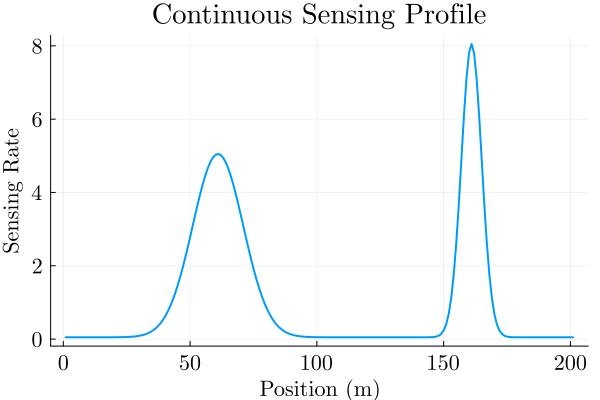

In [18]:
s_values = 0:0.5:L
sensing_profile = [sensing_rate_continuous(s) for s in s_values]
plot(sensing_profile, xlabel="Position (m)", ylabel="Sensing Rate", title="Continuous Sensing Profile", legend=false)

Lap time at optimal speed: 49.19 s
Time-averaged TOTAL clarity at optimal speed: 36.5948
Optimal TOTAL clarity (N=400): 36.5948
Average speed at optimal trajectory: 2.07 m/s


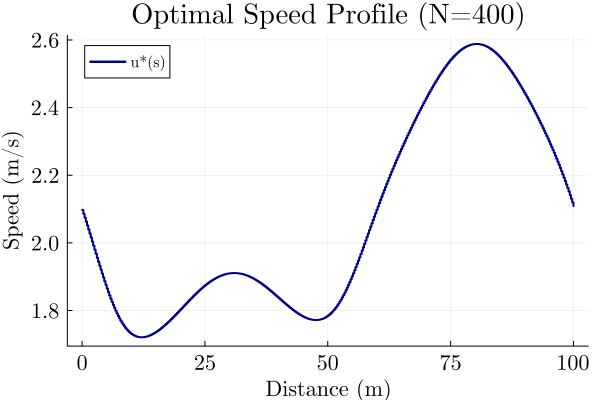

In [19]:
idx_400 = findfirst(==(400), N_values)
@assert idx_400 !== nothing "N = 400 not found in N_values"

T_lap_opt = sum(sim_times[idx_400])
J_avg_opt = results_obj[idx_400]

N_opt = N_values[idx_400]
u_opt = trajectories[idx_400]

s_opt = range(0, L, length=length(u_opt))
p_opt_speed = plot(
    s_opt, u_opt,
    linetype=:step,
    lw=2,
    color=:darkblue,
    xlabel="Distance (m)",
    ylabel="Speed (m/s)",
    title="Optimal Speed Profile (N=$(N_opt))",
    label="u*(s)"
)
# hline!(p_opt_speed, [u_max], lw=2, ls=:dash, color=:red, label="u_max")
savefig(p_opt_speed, "optimal_speed_profile_N$(N_opt).png")
plot!(p_opt_speed)
println("Lap time at optimal speed: $(round(T_lap_opt, digits=2)) s")
println("Time-averaged TOTAL clarity at optimal speed: $(round(J_avg_opt, digits=4))")
println("Optimal TOTAL clarity (N=400): $(round(J_avg_opt, digits=4))")
println("Average speed at optimal trajectory: $(round(mean(u_opt), digits=2)) m/s")
# plot!(ylims=(0, u_max*2))
plot!()


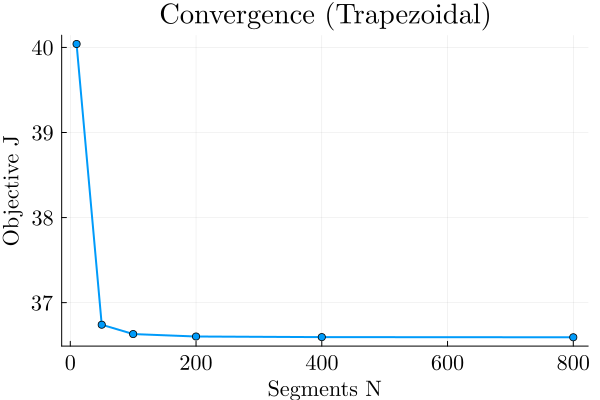

In [20]:
p1 = plot(N_values, results_obj, marker=:circle, title="Convergence (Trapezoidal)", 
          ylabel="Objective J", xlabel="Segments N", legend=false, lw=2)


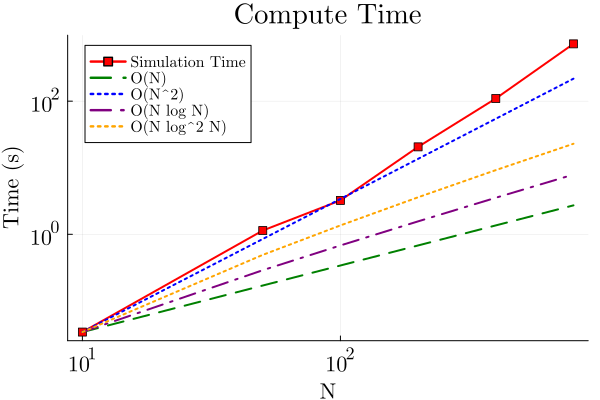

In [21]:

p2 = plot(N_values, results_time, marker=:square, color=:red,
    xaxis=:log, yaxis=:log, title="Compute Time",
    ylabel="Time (s)", xlabel="N", lw=2, label="Simulation Time")
idx = findfirst(!isnan, results_time)
if idx === nothing
    k1 = 1.0
    k2 = 1.0
    k3 = 1.0
else
    k1 = results_time[idx] / N_values[idx]
    k2 = results_time[idx] / (N_values[idx]^2)
    k3 = results_time[idx] / (N_values[idx] * log(N_values[idx]))
    k4 = results_time[idx] / (N_values[idx] * log(N_values[idx])^2)
end

plot!(p2, N_values, k1 .* N_values, lw=2, ls=:dash, color=:green, label="O(N)")
plot!(p2, N_values, k2 .* (N_values .^ 2), lw=2, ls=:dot, color=:blue, label="O(N^2)")
plot!(p2, N_values, k3 .* N_values .* log.(N_values), lw=2, ls=:dashdot, color=:purple, label="O(N log N)")
plot!(p2, N_values, k4 .* N_values .* log.(N_values).^2, lw=2, ls=:dot, color=:orange, label="O(N log^2 N)")

plot!(legend=:topleft)

savefig(p2, "compute_time.png")
plot!()


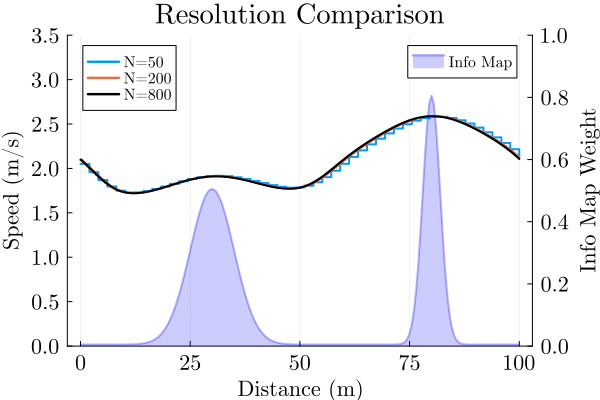

In [ ]:
# Speed Profile Comparison
idx_coarse = findfirst(==(50), N_values)
idx_mid = findfirst(==(200), N_values)
idx_fine = findfirst(==(800), N_values)

p3 = plot(
    title = "Resolution Comparison",
    xlabel = "Distance (m)",
    ylabel = "Speed (m/s)",
    ylims = (0, u_max + 1.0),
    legend=:topleft
)

# Left axis: speed profiles
s_coarse = range(0, L, length=length(trajectories[idx_coarse]))
plot!(p3, s_coarse, trajectories[idx_coarse], linetype=:step, label="N=$(N_values[idx_coarse])", lw=2)

s_mid = range(0, L, length=length(trajectories[idx_mid]))
plot!(p3, s_mid, trajectories[idx_mid], linetype=:step, label="N=$(N_values[idx_mid])", lw=2)

s_fine = range(0, L, length=length(trajectories[idx_fine]))
plot!(p3, s_fine, trajectories[idx_fine], linetype=:step, label="N=$(N_values[idx_fine])", lw=2, color=:black)

# hline!(p3, [u_max], lw=2, ls=:dash, color=:red, label="Max Speed = $(u_max) m/s")
# ylims!(p3, 0, u_max + 0.5)

# Right axis: info map
p3r = twinx(p3)
s_map = 0:0.5:L
plot!(
    p3r,
    s_map,
    sensing_rate_continuous.(s_map),
    color = :blue,
    fill = (0, 0.2, :blue),
    alpha = 0.3,
    ylabel = "Info Map Weight",
    label = "Info Map",
    lw = 2,
    ylims=(0.0, 1.0),
    legend=:topright
)

savefig(p3, "grid_independence_sweep.png")
plot!(p3)

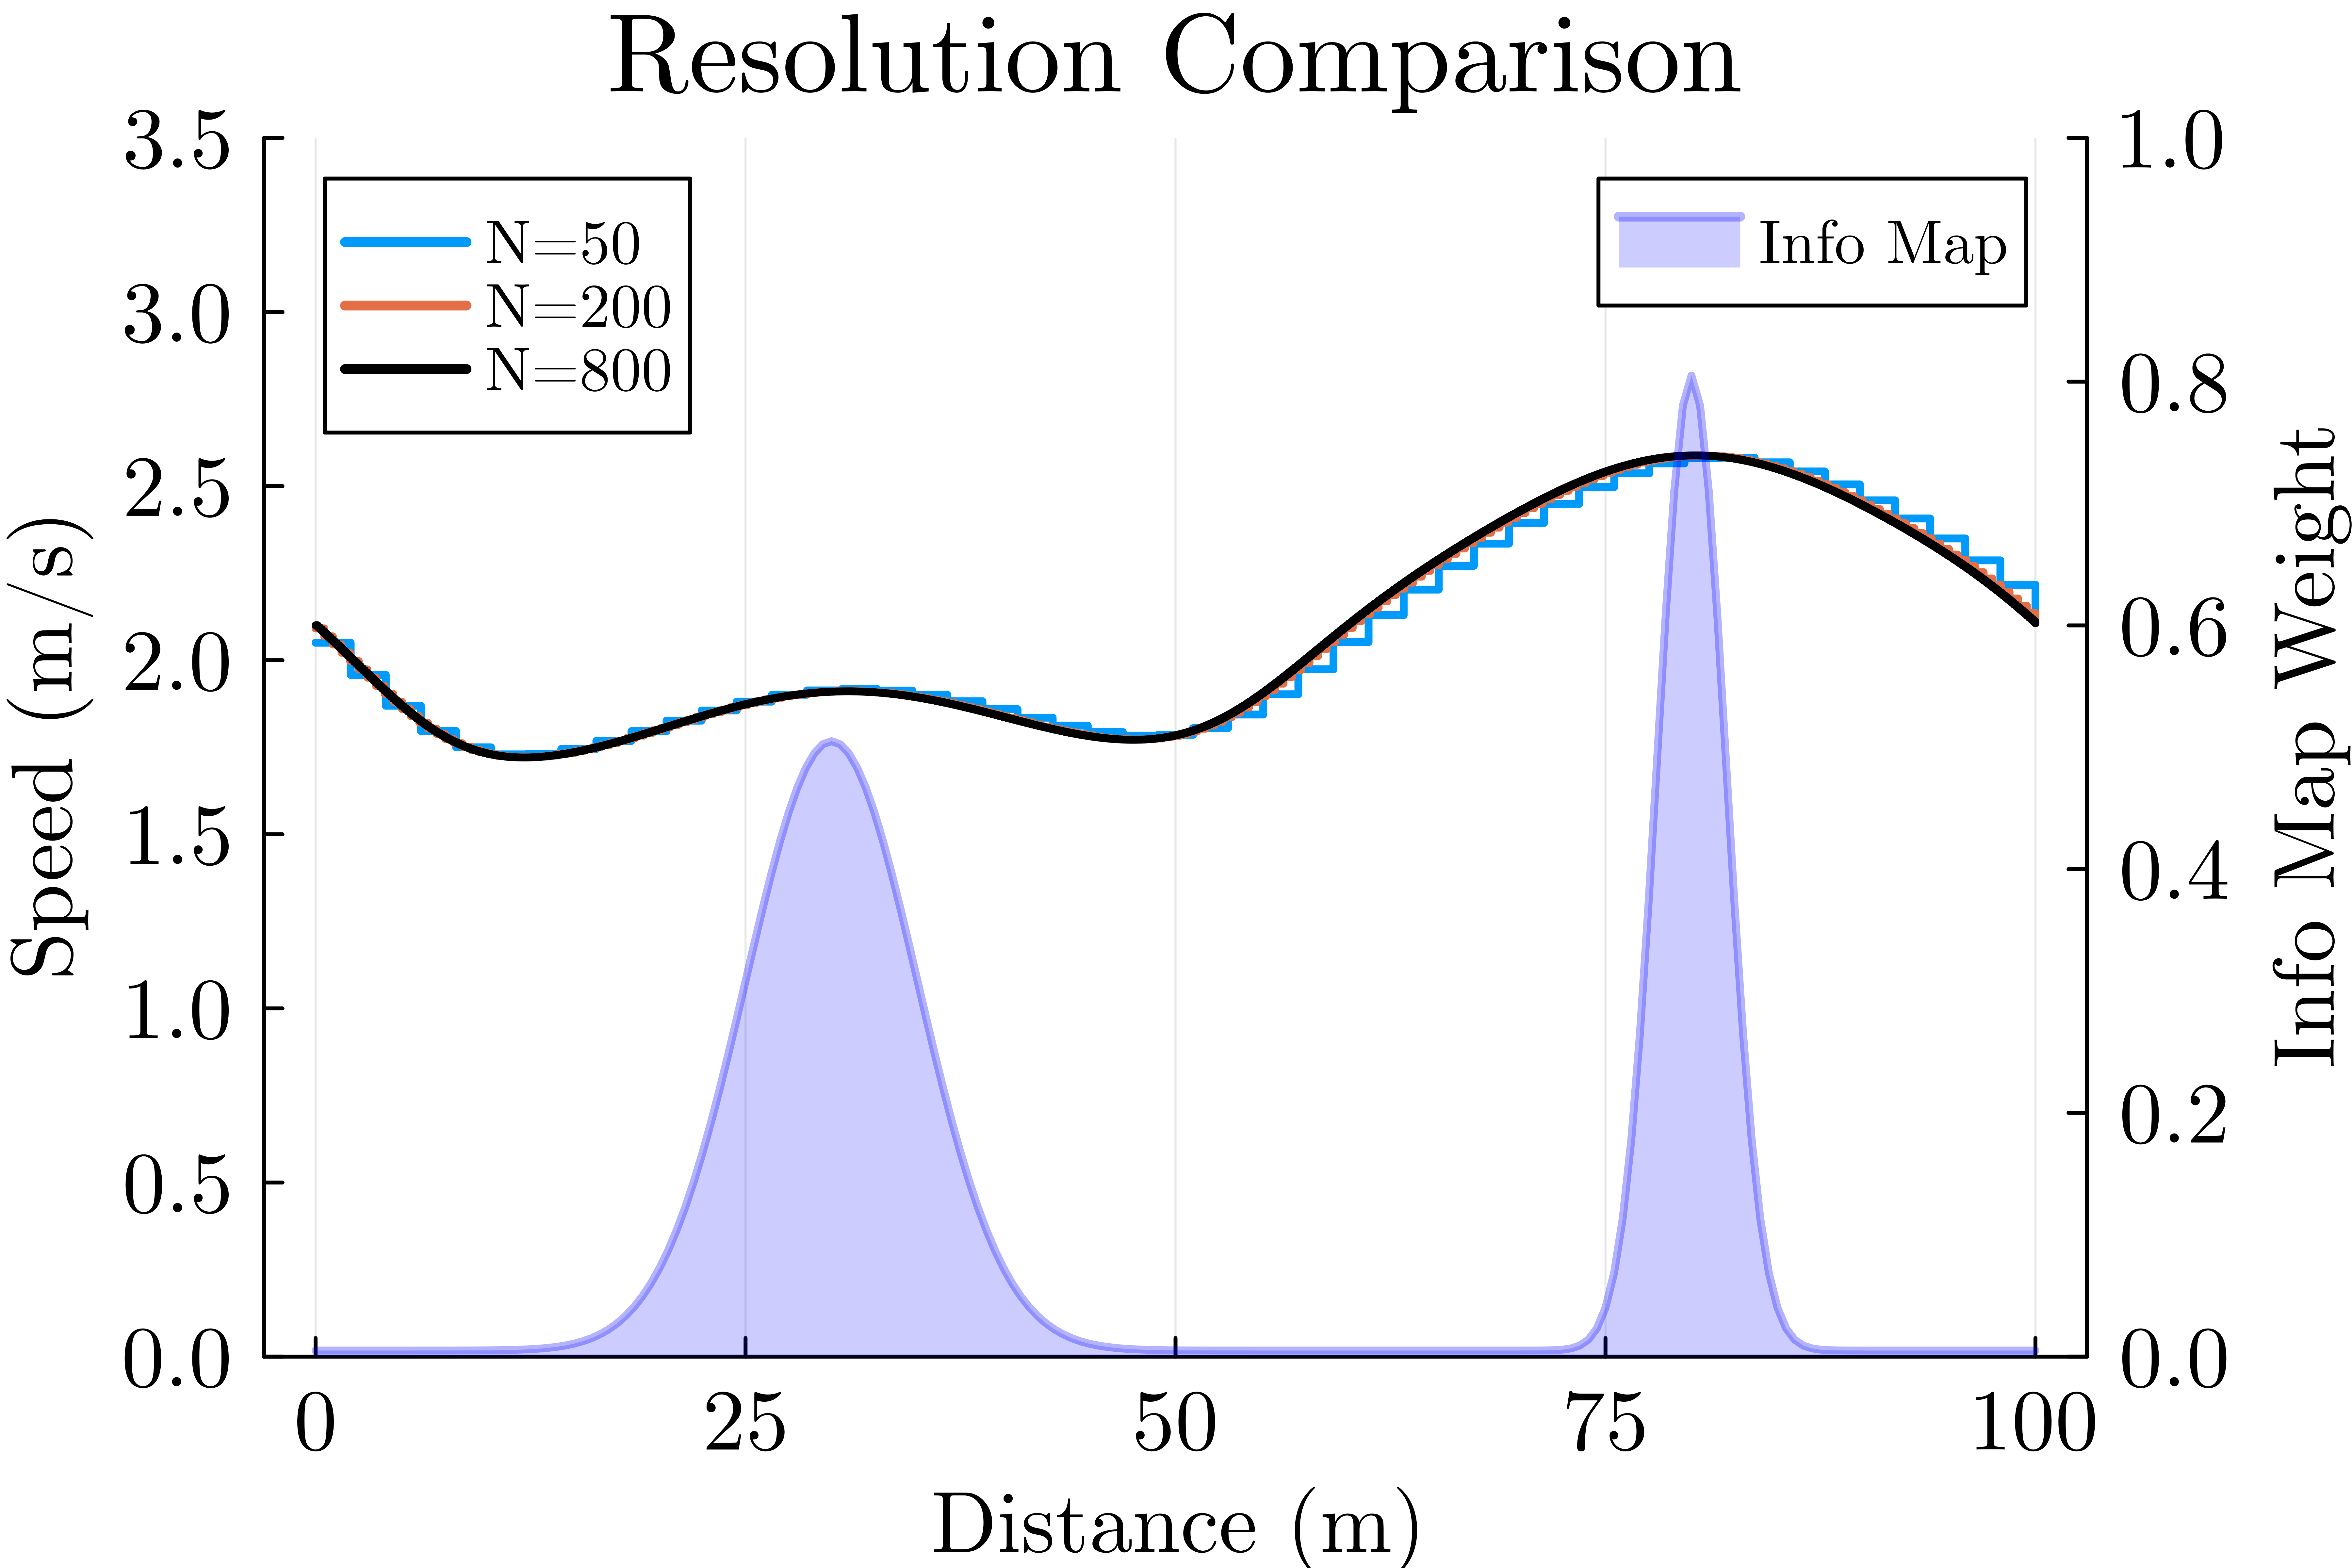

In [31]:
plot!(dpi=1200)
savefig(p3, "grid_independence_sweep.pdf")
plot!()

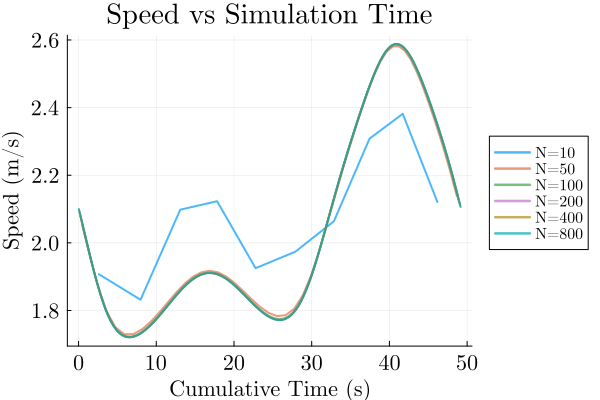

In [25]:
# Speed vs Simulation Time
p = plot(title="Speed vs Simulation Time", xlabel="Cumulative Time (s)", ylabel="Speed (m/s)")
for (i, N) in enumerate(N_values)
    dts = sim_times[i]
    speeds = trajectories[i]
    m = min(length(dts), length(speeds))
    tmid = cumsum(dts[1:m]) .- dts[1:m] ./ 2
    plot!(p, tmid, speeds[1:m], label="N=$(N)", lw=2, alpha=0.7)
    # ylims!(p, 0, u_max + 0.5)
end
plot!(legend=:outerright)
savefig(p, "speed_vs_simtime.png")
plot!()

# Power in Sweep

In [ ]:
# Sweep P_in for fixed resolution N = 400, then co-plot:
# (1) speed vs position, (2) speed vs simulation time

N_fixed = 200
P_in_values = [150.0, 250.0, 350.0, 450.0, 550.0, 650.0, 750.0]

ds = L / N_fixed
s_grid = range(0, L, length=N_fixed)

speed_profiles = Dict{Float64, Vector{Float64}}()
time_mid_profiles = Dict{Float64, Vector{Float64}}()
J_by_power = Dict{Float64, Float64}()
Tlap_by_power = Dict{Float64, Float64}()

println("Running power sweep at N = $N_fixed ...")
for P_in in P_in_values
    print("  P_in = $(round(P_in, digits=1)) W ... ")
    J, solve_t, dts, qs = solve_optimal_trajectory(N_fixed; P_in=P_in)

    if isnan(J) || isempty(dts)
        println("failed")
        continue
    end

    u = ds ./ dts
    tmid = cumsum(dts) .- dts ./ 2

    speed_profiles[P_in] = u
    time_mid_profiles[P_in] = tmid
    J_by_power[P_in] = J
    Tlap_by_power[P_in] = sum(dts)

    println("done | J=$(round(J, digits=3)), Tlap=$(round(sum(dts), digits=2)) s")
    println("  Average speed: $(round(mean(u), digits=2)) m/s")
end


Running power sweep at N = 200 ...
  P_in = 150.0 W ... done | J=34.615, Tlap=84.64 s
  Average speed: 1.17 m/s
  P_in = 250.0 W ... done | J=35.158, Tlap=72.48 s
  Average speed: 1.42 m/s
  P_in = 350.0 W ... done | J=35.61, Tlap=64.24 s
  Average speed: 1.6 m/s
  P_in = 450.0 W ... done | J=35.943, Tlap=58.78 s
  Average speed: 1.74 m/s
  P_in = 550.0 W ... done | J=36.204, Tlap=54.79 s
  Average speed: 1.87 m/s
  P_in = 650.0 W ... done | J=36.42, Tlap=51.69 s
  Average speed: 1.97 m/s
  P_in = 750.0 W ... done | J=36.602, Tlap=49.19 s
  Average speed: 2.07 m/s


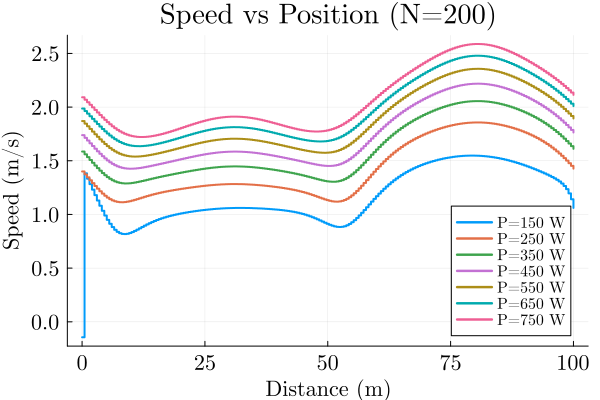

In [ ]:

# Plot 1: speed vs position
p_pos = plot(
    title = "Speed vs Position (N=$N_fixed)",
    xlabel = "Distance (m)",
    ylabel = "Speed (m/s)"
)
for P_in in sort(collect(keys(speed_profiles)))
    plot!(p_pos, s_grid, speed_profiles[P_in], linetype=:step, lw=2, label="P=$(Int(round(P_in))) W")
end
# hline!(p_pos, [u_max], lw=2, ls=:dash, color=:red, label="u_max")
# ylims!(p_pos, 0, u_max + 0.5)
plot!()


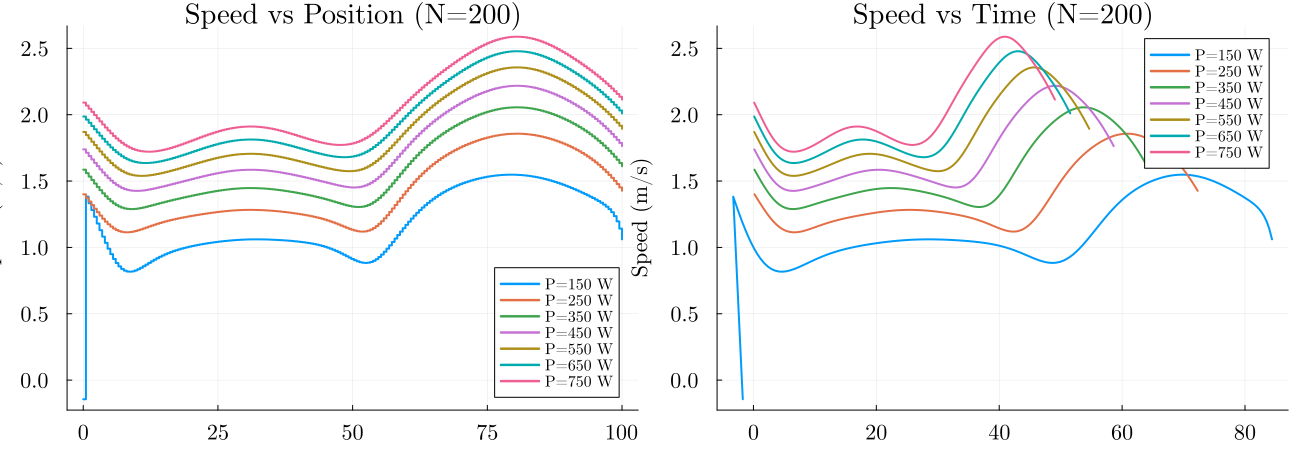

7×3 DataFrame
 Row │ P_in     J_avg    T_lap   
     │ Float64  Float64  Float64 
─────┼───────────────────────────
   1 │   150.0  34.6147  84.6357
   2 │   250.0  35.1579  72.4808
   3 │   350.0  35.61    64.2373
   4 │   450.0  35.9425  58.7765
   5 │   550.0  36.2044  54.7855
   6 │   650.0  36.4197  51.6883
   7 │   750.0  36.602   49.1852


In [ ]:

# Plot 2: speed vs time
p_time = plot(
    title = "Speed vs Time (N=$N_fixed)",
    xlabel = "Simulation Time (s)",
    ylabel = "Speed (m/s)"
)
for P_in in sort(collect(keys(speed_profiles)))
    plot!(p_time, time_mid_profiles[P_in], speed_profiles[P_in], lw=2, label="P=$(Int(round(P_in))) W")
end
# hline!(p_time, [u_max], lw=2, ls=:dash, color=:red, label="u_max")
# ylims!(p_time, 0, u_max + 0.5)

# Co-plot
p_coplot = plot(p_pos, p_time, layout=(1, 2), size=(1300, 450))
display(p_coplot)
savefig(p_coplot, "power_sweep_N400_coplot.png")

# Optional summary table
power_sweep_table = DataFrame(
    P_in = sort(collect(keys(J_by_power))),
    J_avg = [J_by_power[P] for P in sort(collect(keys(J_by_power)))],
    T_lap = [Tlap_by_power[P] for P in sort(collect(keys(Tlap_by_power)))]
)
println(power_sweep_table)

# "Manual" Sim of constant speed

In [ ]:
# Simulate at constant speed equivalent to power input
P_in = P_budget # Same as default in solve_optimal_trajectory
N_sim = N_values[test_idx]  # Use finest grid
ds = L / N_sim
S_vals = [get_segment_S((i-1)*ds, i*ds) for i in 1:N_sim]
footprint_matrix = get_footprint_matrix(N_sim, L, sigma=10.0) # Match sigma with optimizer

u_const = cbrt((P_in - kh) / km)
dt_const = ds / u_const

q_sim = zeros(N_sim + 1, N_sim)
q_sim[1, :] .= 0.5  

num_laps = 10 # Run for multiple laps to reach a steady-state limit cycle

for lap in 1:num_laps
    if lap > 1
        q_sim[1, :] .= q_sim[N_sim+1, :]
    end
    
    for i in 1:N_sim
        for j in 1:N_sim
            # NEW: Use footprint matrix
            S = S_vals[j] * footprint_matrix[i, j]
            
            q_curr = q_sim[i, j]
            q_next = q_curr  
            
            for _ in 1:50
                f_curr = S * (1 - q_curr)^2 - alpha * q_curr^2
                f_next = S * (1 - q_next)^2 - alpha * q_next^2
                
                res = q_next - q_curr - 0.5 * dt_const * (f_curr + f_next)
                dres = 1 - 0.5 * dt_const * (-2 * S * (1 - q_next) - 2 * alpha * q_next)
                
                q_next -= res / dres
            end
            q_sim[i+1, j] = clamp(q_next, 0.0, 1.0)
        end
    end
end

T_lap_const = N_sim * dt_const
# NEW: Multiply by ds inside the sum
J_avg_const = sum(0.5 * (q_sim[i, j] + q_sim[i+1, j]) * dt_const * ds for i in 1:N_sim, j in 1:N_sim) / T_lap_const

println("Time-averaged TOTAL clarity at constant speed: $(round(J_avg_const, digits=4)) (Max: $L)")
println("Optimal TOTAL clarity (N=$(N_sim)): $(round(results_obj[test_idx], digits=4)) (Max: $L)")
println("Improvement from optimization: $(round((results_obj[test_idx] - J_avg_const) / J_avg_const * 100, digits=2))%")

Time-averaged TOTAL clarity at constant speed: 36.4954 (Max: 100.0)
Optimal TOTAL clarity (N=400): 36.5948 (Max: 100.0)
Improvement from optimization: 0.27%


# $\alpha$ Sensitivity

In [ ]:
# ==========================================
# 1. Physics & Environment
# ==========================================
const L = 100.0             # Total Path Length (m)
const P_budget = 450.0     # Average Power In (W)
const u_min = 0.0           # Min feasible speed (m/s)
const u_max = 2.5           # Max speed (m/s)
const kh = 10.0             # Hotel Load (W)
const km = 83.0              # Drag Coefficient
alpha_vals = 0.01:0.1:1.0          # Decay rate
const S_scale = 1.0         # Sensing magnitude

# Environment Map (Gaussian Hotspots)
function sensing_rate_continuous(s)
    peak1 = 0.5 * exp(-((s - 30)^2) / (2 * 5^2)) 
    peak2 = 0.8 * exp(-((s - 80)^2) / (2 * 2^2)) # Sharper peak
    return 0.05 + S_scale * (peak1 + peak2)
end

# function sensing_rate_continuous(s)
#     return 1.0  # Uniform sensing rate for simplicity
# end

# Anti-aliasing: Integrate S over the segment
function get_segment_S(s_start, s_end)
    val, err = quadgk(sensing_rate_continuous, s_start, s_end)
    return val / (s_end - s_start)
end


get_segment_S (generic function with 1 method)

In [ ]:

# ==========================================
# Optimization Routine (Pure Power Budget, Distance-Based Sensing)
# ==========================================
function solve_optimal_trajectory_vary_alpha(N, alpha; P_in=750.0, sigma=20.0)
    ds = L / N
    S_vals = [get_segment_S((i-1)*ds, i*ds) for i in 1:N]
    
    # NEW: Precompute the sensor footprint matrix
    footprint_matrix = get_footprint_matrix(N, L, sigma=10.0)
    
    model = Model(Ipopt.Optimizer)
    set_silent(model)
    
    # --- Variables ---
    @variable(model, ds/u_max <= dt[1:N] <= ds/u_min)
    
    # 2D Spatiotemporal Matrix
    # Rows (1:N+1) = Time/Position steps, Columns (1:N) = Spatial segments
    @variable(model, 0 <= q[1:N+1, 1:N] <= 1.0)
    
    # Explicit lap time variable (No upper bound!)
    @variable(model, T_lap >= 0)
    @constraint(model, T_lap == sum(dt[i] for i in 1:N))
    
    # Auxiliary variable for Average Total Clarity
    @variable(model, 0 <= J_avg <= N)
    
    # Reformulated Fractional Objective Constraint (Sums over all space and time)
    @NLconstraint(model, J_avg * T_lap == sum( 0.5 * (q[i, j] + q[i+1, j]) * dt[i] for i in 1:N, j in 1:N ))
    
    # Linear Objective
    @objective(model, Max, J_avg)
    
    # --- Constraints ---
    
    # Energy generated scales with lap time (Power Budget)
    @variable(model, E_avail >= 0)
    @constraint(model, E_avail == P_in * T_lap)
    
    # 1. Global Energy Constraint (Total energy consumed <= E_avail)
    @NLconstraint(model, sum(kh * dt[i] + km * (ds / dt[i])^3 * dt[i] for i in 1:N) <= E_avail)
    
    # Clarity Dynamics
    for i in 1:N          # Time step index (Robot is physically at segment i)
        for j in 1:N      # Spatial segment index being updated
            
            # NEW: S is the environment's base rate at j, scaled by the robot's footprint from i to j
            S = S_vals[j] * footprint_matrix[i, j]
            
            @NLconstraint(model, 
                q[i+1, j] == q[i, j] + 0.5 * dt[i] * (
                    (S * (1 - q[i, j])^2 - alpha * q[i, j]^2) + 
                    (S * (1 - q[i+1, j])^2 - alpha * q[i+1, j]^2)
                )
            )
        end
    end
    
    # 3. Initial Condition (Cyclic boundary condition)
    @constraint(model, [j=1:N], q[1, j] == q[N+1, j])
    
    # --- Warm Start ---
    u_nominal = 0.5 * (u_min + u_max)
    set_start_value.(dt, ds / u_nominal)
    set_start_value.(q, 0.5)                 # Broadcasts over the full matrix
    set_start_value(T_lap, N * ds / u_nominal)
    set_start_value(J_avg, 0.5 * N)          # Adjusted to scale with N segments
    set_start_value(E_avail, P_in * (N * ds / u_nominal))

    # --- Solve ---
    t_start = time()
    optimize!(model)
    solve_time = time() - t_start
    
    # Return Results
    if termination_status(model) in [MOI.LOCALLY_SOLVED, MOI.OPTIMAL]
        return objective_value(model), solve_time, value.(dt), value.(q)
    else
        println("Warning: Optimizer failed.")
        return NaN, NaN, [], []
    end
end

solve_optimal_trajectory_vary_alpha (generic function with 1 method)

In [ ]:
N = 100;
results_obj = []
results_time = []
trajectories = []
sim_times = []
results_q = []

println("Running Grid Independence Sweep...")
for alpha in alpha_vals
    print(" Alpha  = $alpha ... ")
    obj, t, dts, qs = solve_optimal_trajectory_vary_alpha(N, alpha; P_in=P_budget, sigma=20.0   )
    push!(results_obj, obj)
    push!(results_time, t)
    push!(sim_times, dts)
    push!(results_q, qs)
    
    # Store speed profile for plotting
    speeds = (L/N) ./ dts
    push!(trajectories, speeds)
    println("Done. J = $(round(obj, digits=2)), Time = $(round(t, digits=3))s")
end


Running Grid Independence Sweep...
 Alpha  = 0.01 ... Done. J = 58.9, Time = 2.86s
 Alpha  = 0.11 ... Done. J = 28.47, Time = 3.783s
 Alpha  = 0.21 ... Done. J = 21.87, Time = 5.836s
 Alpha  = 0.31 ... Done. J = 18.5, Time = 6.061s
 Alpha  = 0.41 ... Done. J = 16.36, Time = 6.373s
 Alpha  = 0.51 ... Done. J = 14.87, Time = 5.954s
 Alpha  = 0.61 ... Done. J = 13.75, Time = 3.942s
 Alpha  = 0.71 ... Done. J = 12.87, Time = 5.002s
 Alpha  = 0.81 ... Done. J = 12.16, Time = 4.567s
 Alpha  = 0.91 ... Done. J = 11.57, Time = 5.6s


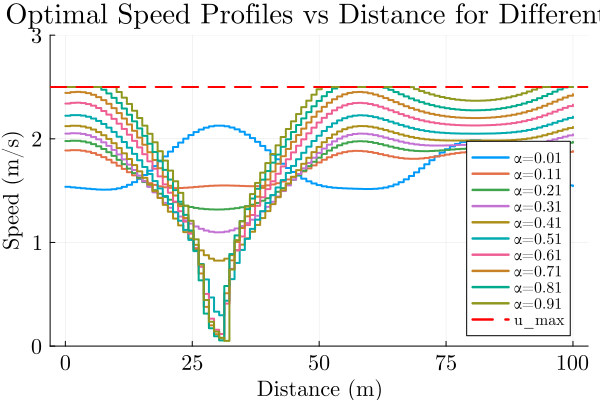

"c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\simple_sensitivity\\speed_profiles_vs_alpha.png"

In [ ]:
p_alpha = plot(
    title = "Optimal Speed Profiles vs Distance for Different α",
    xlabel = "Distance (m)",
    ylabel = "Speed (m/s)"
)

for (i, α) in enumerate(alpha_vals)
    u = trajectories[i]
    isempty(u) && continue
    s = range(0, L, length=length(u))
    plot!(p_alpha, s, u, linetype=:step, lw=2, label="α=$(round(α, digits=2))")
end

hline!(p_alpha, [u_max], lw=2, ls=:dash, color=:red, label="u_max")
ylims!(p_alpha, 0, u_max + 0.5)
display(p_alpha)
savefig(p_alpha, "speed_profiles_vs_alpha.png")